In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import any packages you want to use below

# statsmodels for the regression / GLM stuff
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

# ISLP helpers from the labs
from ISLP.models import (ModelSpec as MS, summarize, poly)
from ISLP import confusion_table

# the sklearn classifiers we need for part 2
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 100




# STA 141A Final Project


In this final project, you will be required to learn and apply the linear regression methods and classification methods in the lecture to analyze two datasets.

**Reading**

- For linear regression methods, the reference coding lab is in section `3.6` in the `ISL` book.
- For classification, the reference coding lab is in section `4.7` of the same book.

**Grading (100 pts total)**
- Plots should be clearly labeled, readable, and well annotated.
- For questions that involve calculations, you must show all steps used to obtain the final numerical results.
- Any answer submitted without supporting code and output will receive 0 points.
- ***Readability requirement***: Submitted work must be well organized and easy to follow. Up to 10 points may be deducted for poor readability.

**AI Policy**

Use of AI tools (including ChatGPT, Copilot, Gemini, etc.) is strictly prohibited for this assignment/exam. All submitted work must represent your own thinking and analysis. Any suspicious or AI-generated responses will be referred to `Student Conduct and Integrity` for academic misconduct review.

**Submission**
- When you’re done, go to `Kernel` -> `Restart & Run All` to ensure the notebook runs cleanly from top to bottom.
- Export your work as `finalproject.pdf` and upload it to Gradescope.


For this project I worked through two datasets: `Auto` for the regression part (3.6) and `Weekly` for the classification part (4.7). I tried to follow the labs pretty closely but also poked around a bit on my own where it seemed useful. Each part has the code, the output it produced, the plots, and my thoughts on what's actually going on.

### 1. Simple Linear Regression

This question involves the use of simple linear regression on the `Auto` data set.

First thing: when I loaded the data, `horsepower` came in as text instead of numbers. Turns out there are a few rows where it's stored as "?" (missing values). That's the usual gotcha with this dataset, so I dropped those rows and converted the column to a float. That leaves 392 rows to work with.

In [2]:
Auto = pd.read_csv('Auto.csv')

# horsepower is text because of some '?' entries - drop those and convert
Auto = Auto[Auto['horsepower'] != '?'].copy()
Auto['horsepower'] = Auto['horsepower'].astype(float)
Auto = Auto.reset_index(drop=True)

print("Rows left after dropping the '?' horsepower values:", Auto.shape[0])
Auto.head()

Rows left after dropping the '?' horsepower values: 392


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


(a) [5 pts] Use the sm.0LS() function to perform a simple linear regression with mpg as the response and horsepower as the predictor. Use the summarize() function to print the results. Comment on the output. For example:
- i. Is there a relationship between the predictor and the response?
- ii. How strong is the relationship between the predictor and the response?
- iii. Is the relationship between the predictor and the response positive or negative?
- iv. What is the predicted mpg associated with a horsepower of 98 ? What are the associated $95\%$ confidence and prediction intervals?

In [3]:
y = Auto['mpg']
design = MS(['horsepower']).fit(Auto)
X = design.transform(Auto)

results_a = sm.OLS(y, X).fit()
summarize(results_a)


,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [4]:

print(f"R-squared = {results_a.rsquared:.4f}")
print(f"RSE = {np.sqrt(results_a.scale):.4f}")
print(f"Average mpg = {y.mean():.4f}")
print(f"RSE as a % of average mpg = {100*np.sqrt(results_a.scale)/y.mean():.2f}%")

R-squared = 0.6059
RSE = 4.9058
Average mpg = 23.4459
RSE as a % of average mpg = 20.92%


And here's the prediction at `horsepower = 98`, with both intervals:

In [5]:
new_df = pd.DataFrame({'horsepower': [98]})
newX = design.transform(new_df)
pred = results_a.get_prediction(newX)

print("Predicted mpg:", np.round(pred.predicted_mean, 4))
print("95% confidence interval:", np.round(pred.conf_int(alpha=0.05), 4))
print("95% prediction interval:", np.round(pred.conf_int(obs=True, alpha=0.05), 4))

Predicted mpg: [24.4671]
95% confidence interval: [[23.9731 24.9611]]
95% prediction interval: [[14.8094 34.1248]]


**So what does this tell us?**

*Is there a relationship?* Yeah, definitely. The t-stat on horsepower is about -24.5 and the p-value is basically zero, so there's no real doubt here - the two are related.

*How strong?* Reasonably strong, but not the whole story. The R-squared is around 0.61, so horsepower by itself accounts for about 61% of the variation in mpg. The typical miss (the RSE) is about 4.9 mpg, which is roughly a fifth of the average mpg - so the predictions are useful but you wouldn't bet your life on any single one.

*Positive or negative?* Negative. The slope is about -0.158, so every extra unit of horsepower knocks off about 0.16 mpg. Makes sense - beefier engines drink more gas.

*Prediction at hp = 98:* about 24.47 mpg. The confidence interval (for the average car with that horsepower) is roughly (23.97, 24.96), and the prediction interval (for one specific car) is much wider at (14.81, 34.12). The wider one is expected - predicting a single car has to account for all the random variation between individual cars, not just the uncertainty in the average.

(b) [3 pts] Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method to display the least squares regression line.


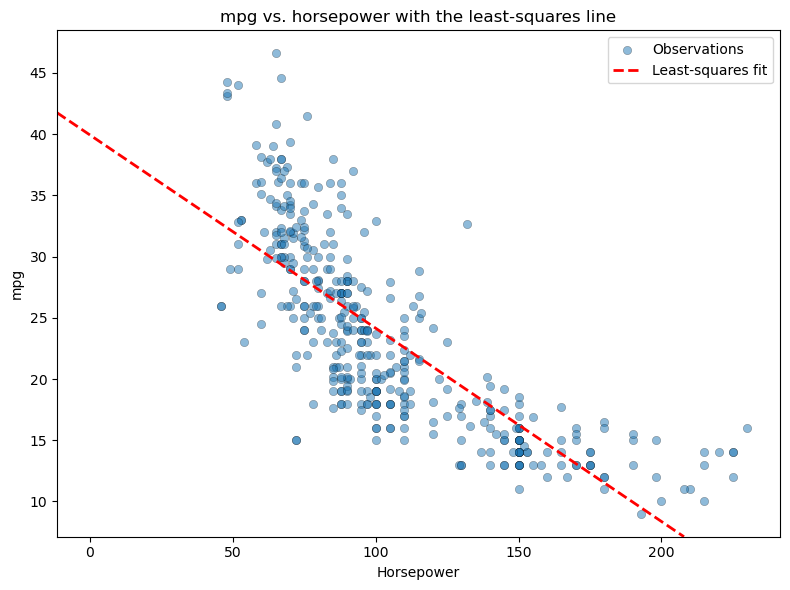

In [6]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Auto['horsepower'], Auto['mpg'], alpha=0.5, edgecolor='k',
           linewidth=0.3, label='Observations')

b0, b1 = results_a.params['intercept'], results_a.params['horsepower']
ax.axline((0, b0), slope=b1, color='red', linestyle='--', linewidth=2,
          label='Least-squares fit')

ax.set_xlabel('Horsepower')
ax.set_ylabel('mpg')
ax.set_title('mpg vs. horsepower with the least-squares line')
ax.legend()
plt.tight_layout()
plt.show()

You can see the downward trend clearly. But look at the ends - the points kind of curve *above* the line at both the low and high horsepower extremes. The straight line is doing an okay job in the middle but missing that bend. I'll come back to this.

(c) [4 pts] Produce some of diagnostic plots of the least squares regression fit as described in the lab. Comment on any problems you see with the fit.

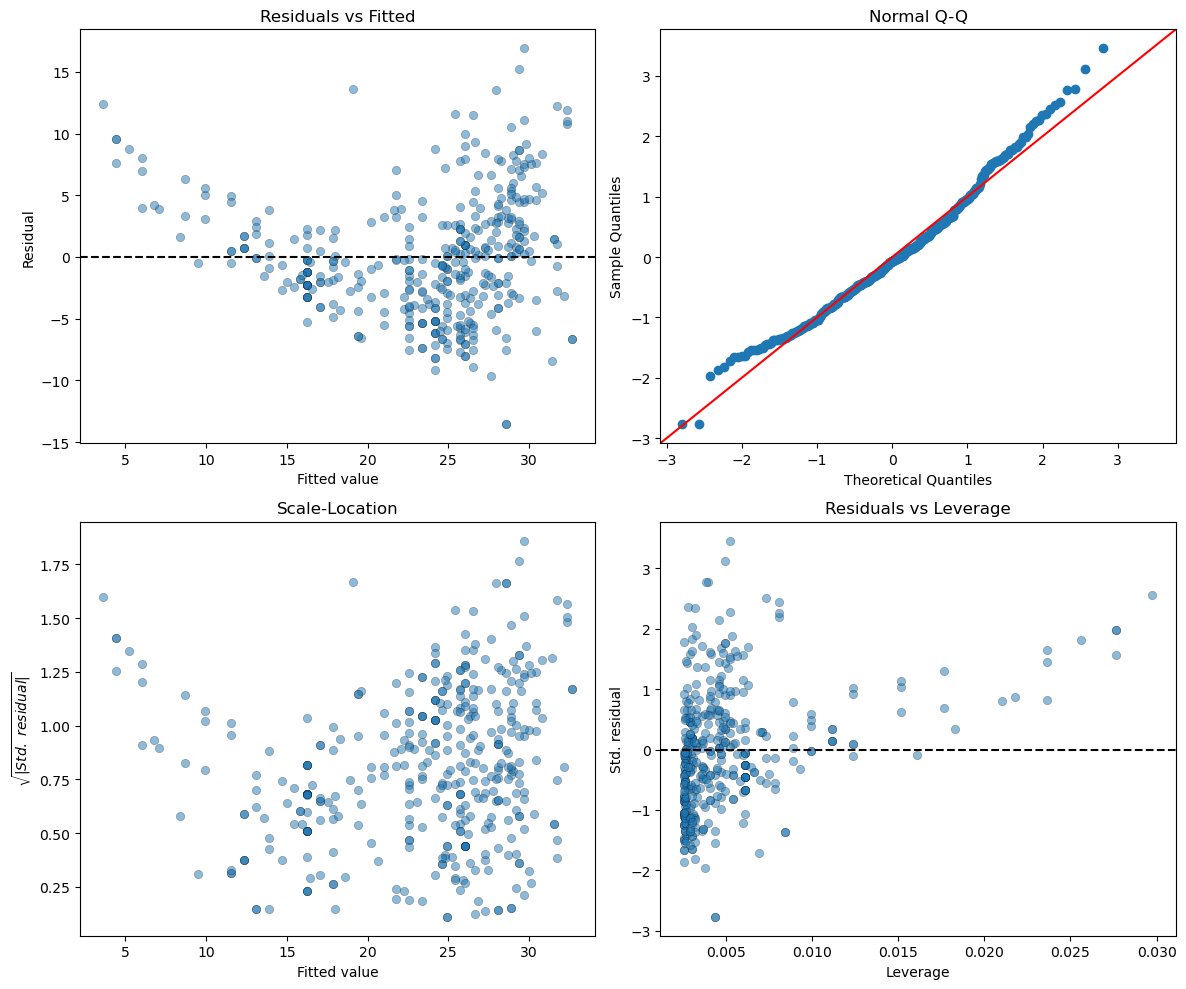

Point with the largest leverage: 115


In [7]:
infl_a = results_a.get_influence()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# residuals vs fitted
ax = axes[0, 0]
ax.scatter(results_a.fittedvalues, results_a.resid, alpha=0.5,
           edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', ls='--')
ax.set_xlabel('Fitted value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted')

# Q-Q plot
ax = axes[0, 1]
sm.qqplot(infl_a.resid_studentized_internal, line='45', ax=ax)
ax.set_title('Normal Q-Q')

# scale-location
ax = axes[1, 0]
ax.scatter(results_a.fittedvalues,
           np.sqrt(np.abs(infl_a.resid_studentized_internal)),
           alpha=0.5, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Fitted value'); ax.set_ylabel(r'$\sqrt{|Std.\ residual|}$')
ax.set_title('Scale-Location')

# residuals vs leverage
ax = axes[1, 1]
ax.scatter(infl_a.hat_matrix_diag, infl_a.resid_studentized_internal,
           alpha=0.5, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', ls='--')
ax.set_xlabel('Leverage'); ax.set_ylabel('Std. residual')
ax.set_title('Residuals vs Leverage')

plt.tight_layout()
plt.show()

print("Point with the largest leverage:", np.argmax(infl_a.hat_matrix_diag))

**What's wrong with the fit?**

The residuals-vs-fitted plot is the big tell. The residuals make a clear U-shape - positive at the low and high ends, negative in the middle. That's the classic "you fit a line but the truth is curved" pattern, and it lines up exactly with that bend I noticed in the scatterplot. A line just isn't the right shape here.

The scale-location plot also drifts upward, which means the spread of the residuals grows as the fitted values grow (non-constant variance). And the Q-Q plot has the upper tail creeping above the 45-degree line, so the residuals are a little right-skewed instead of perfectly normal.

Bottom line: the straight-line model is leaving structure on the table. Something non-linear would fit better.

(d) [3 pts] Produce a scatterplot matrix which includes all of the variables in the data set.

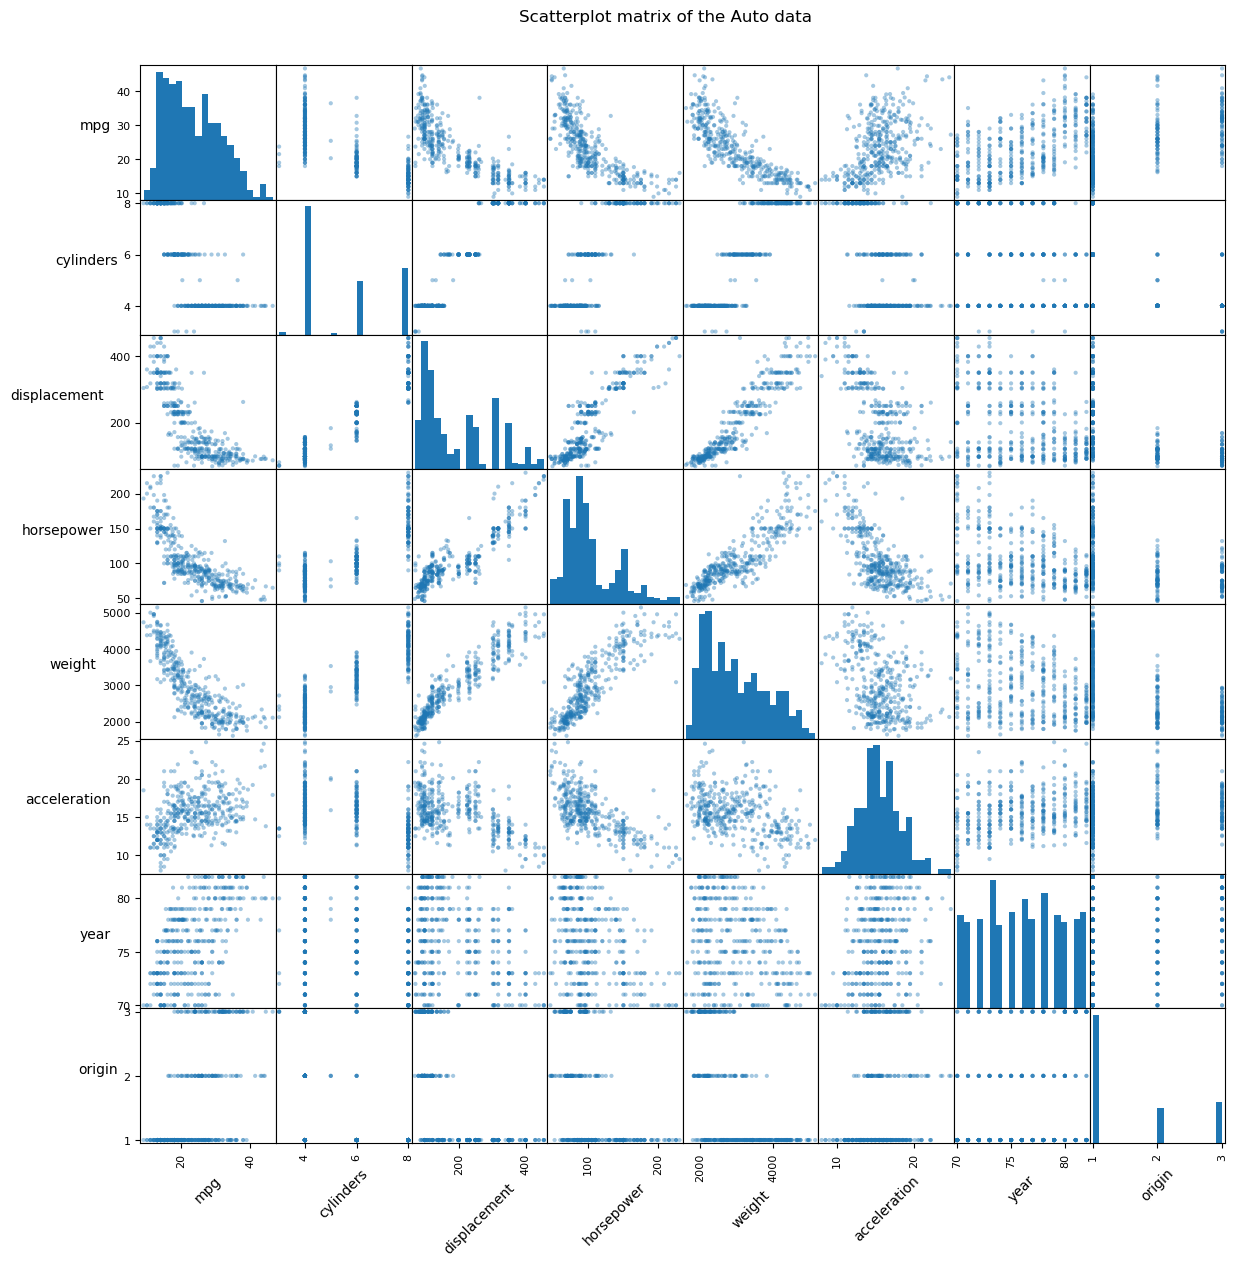

In [8]:
# drop 'name' since it's just text labels
num_cols = Auto.columns.drop('name')
axes = pd.plotting.scatter_matrix(Auto[num_cols], figsize=(14, 14),
                                  diagonal='hist', alpha=0.4,
                                  hist_kwds={'bins': 20})
for ax in axes.ravel():
    ax.xaxis.label.set_rotation(45)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.suptitle('Scatterplot matrix of the Auto data', y=0.92)
plt.show()

A lot to take in, but a few things jump out. `mpg` clearly drops as `displacement`, `horsepower`, and `weight` go up - and those three are obviously tangled up with each other too (the plots between them are basically straight lines). `mpg` goes *up* with `year` and `acceleration`. And several of these relationships look curved rather than straight, which is consistent with what I saw earlier.

(e) [3 pts] Compute the matrix of correlations between the variables using the DataFrame.corr() method.

In [9]:
corr = Auto[num_cols].corr()
corr.round(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000,-0.778,-0.805,-0.778,-0.832,0.423,0.581,0.565
cylinders,-0.778,1.000,0.951,0.843,0.898,-0.505,-0.346,-0.569
displacement,-0.805,0.951,1.000,0.897,0.933,-0.544,-0.370,-0.615
horsepower,-0.778,0.843,0.897,1.000,0.865,-0.689,-0.416,-0.455
weight,-0.832,0.898,0.933,0.865,1.000,-0.417,-0.309,-0.585
acceleration,0.423,-0.505,-0.544,-0.689,-0.417,1.000,0.290,0.213
year,0.581,-0.346,-0.370,-0.416,-0.309,0.290,1.000,0.182
origin,0.565,-0.569,-0.615,-0.455,-0.585,0.213,0.182,1.000


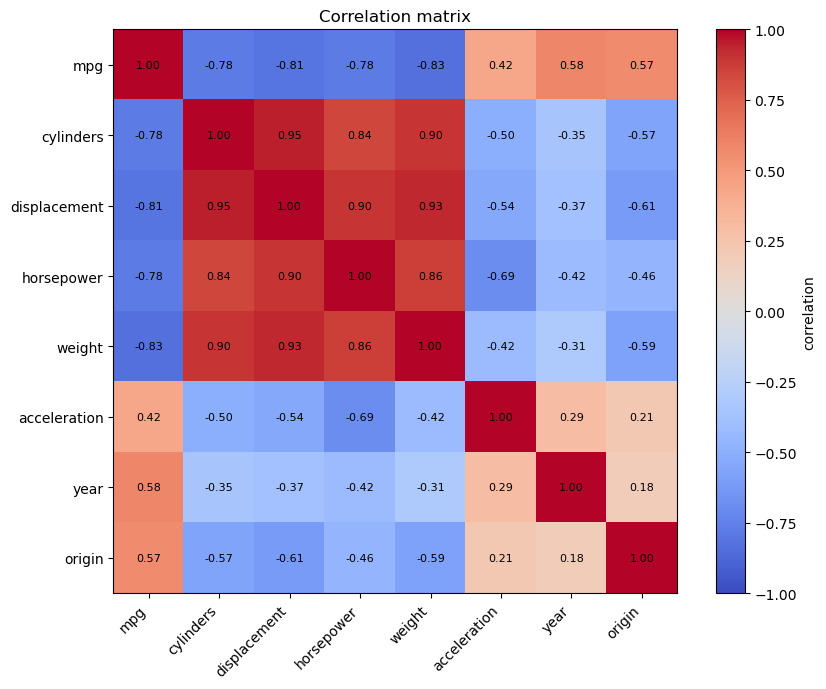

In [10]:
# easier to read as a heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                color='black', fontsize=8)
fig.colorbar(im, ax=ax, label='correlation')
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

This puts numbers on the picture. `mpg` is strongly *negatively* tied to `weight` (-0.83), `displacement` (-0.81), and `horsepower` (-0.78), and positively to `year` (0.58) and `origin` (0.57). The thing I'd flag for later: the four "engine size" variables (cylinders, displacement, horsepower, weight) are all correlated above 0.84 with each other. That's going to cause collinearity headaches once we throw them all into one model.

(f) [5 pts] Use the sm.0LS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. For instance:
- i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.
- ii. Which predictors appear to have a statistically significant relationship to the response?
- iii. What does the coefficient for the year variable suggest?

In [11]:
terms = list(Auto.columns.drop(['mpg', 'name']))
X_mult = MS(terms).fit_transform(Auto)
results_f = sm.OLS(y, X_mult).fit()
summarize(results_f)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [12]:
print(f"R-squared = {results_f.rsquared:.4f}")
print(f"RSE = {np.sqrt(results_f.scale):.4f}")

R-squared = 0.8215
RSE = 3.3277


To check whether there's *any* relationship overall, I compared the full model against a model with just an intercept using `anova_lm`:

In [13]:
X_null = MS([]).fit_transform(Auto)
results_null = sm.OLS(y, X_null).fit()
anova_lm(results_null, results_f)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,391.0,23818.993469,0.0,NaN,NaN,NaN
1,384.0,4252.212530,7.0,19566.780939,252.428045,2.037106e-139


**Reading the output:**

*Is there a relationship at all?* Yes, easily. The ANOVA F-stat is huge (around 252) and the p-value is essentially zero, so at least some of these predictors matter. The model now explains about 82% of the variance, a big jump from the single-predictor model.

*Which predictors are actually significant?* Once you hold the others fixed, weight, year, origin, and displacement have tiny p-values and carry their weight. But cylinders, horsepower, and acceleration *don't* come out significant - which surprised me at first, since horsepower was super significant on its own in part (a). The explanation is collinearity: weight and displacement are so correlated with horsepower that they soak up most of its explanatory power, leaving horsepower with little to add on top.

*What about the year coefficient?* It's about +0.75. So holding everything else constant, cars gained roughly three-quarters of an mpg per model year. Fuel economy genuinely improved over the years in this data - that's a nice, clean result.

(g) [5 pts] Produce some of diagnostic plots of the linear regression fit as described in the reference lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

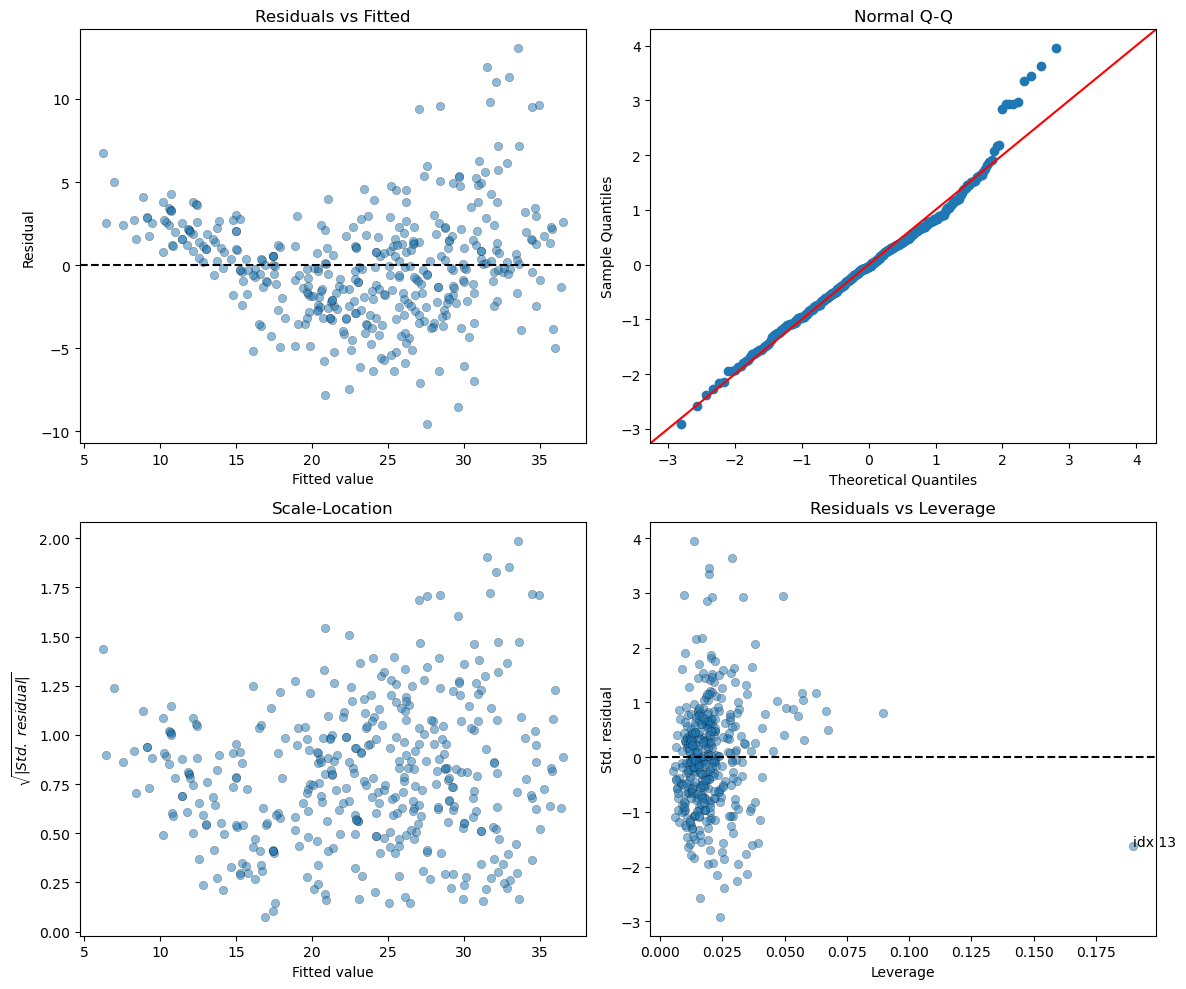

Highest-leverage observation: index 13 (leverage = 0.1899 )
Biggest outlier: index 320 (studentized residual = 3.952 )


In [14]:
infl_f = results_f.get_influence()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.scatter(results_f.fittedvalues, results_f.resid, alpha=0.5,
           edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', ls='--')
ax.set_xlabel('Fitted value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted')

ax = axes[0, 1]
sm.qqplot(infl_f.resid_studentized_internal, line='45', ax=ax)
ax.set_title('Normal Q-Q')

ax = axes[1, 0]
ax.scatter(results_f.fittedvalues,
           np.sqrt(np.abs(infl_f.resid_studentized_internal)),
           alpha=0.5, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Fitted value'); ax.set_ylabel(r'$\sqrt{|Std.\ residual|}$')
ax.set_title('Scale-Location')

ax = axes[1, 1]
lev = infl_f.hat_matrix_diag
ax.scatter(lev, infl_f.resid_studentized_internal, alpha=0.5,
           edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', ls='--')
ax.set_xlabel('Leverage'); ax.set_ylabel('Std. residual')
ax.set_title('Residuals vs Leverage')
hi = np.argmax(lev)
ax.annotate(f'idx {hi}', (lev[hi], infl_f.resid_studentized_internal[hi]))

plt.tight_layout()
plt.show()

print("Highest-leverage observation: index", np.argmax(lev),
      "(leverage =", round(lev.max(), 4), ")")
worst = np.argmax(np.abs(infl_f.resid_studentized_internal))
print("Biggest outlier: index", worst,
      "(studentized residual =", round(infl_f.resid_studentized_internal[worst], 3), ")")

**Any problems?** A few, yeah.

The residuals-vs-fitted plot still has a slight curve to it, and the spread clearly fans out as the fitted values get bigger - so there's still some non-linearity and some non-constant variance. The model's decent but not perfectly specified; transforming `mpg` (a log, say) would probably tidy this up.

*Outliers:* a handful of points have studentized residuals up near +3.5 - these are cars that get noticeably better mileage than the model expects. So yes, a few unusually large outliers.

*Leverage:* one point (around index 13) sits way out to the right on the leverage axis, well separated from everything else. Its residual is small though, so it's not really yanking the fit around - it's a high-leverage point but not an influential troublemaker.

(h) [6 pts] Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [15]:
# throw in a few interactions that seem physically plausible
X_int = MS(terms + [('horsepower', 'weight'),
                    ('displacement', 'year'),
                    ('acceleration', 'horsepower')]).fit_transform(Auto)
results_h = sm.OLS(y, X_int).fit()
summarize(results_h)

,coef,std err,t,P>|t|
intercept,-30.035500,8.237000,-3.647,0.000
cylinders,0.335100,0.290000,1.156,0.248
displacement,0.126400,0.038000,3.331,0.001
horsepower,-0.139300,0.037000,-3.722,0.000
weight,-0.008900,0.001000,-9.925,0.000
acceleration,0.289400,0.164000,1.762,0.079
year,1.063200,0.093000,11.383,0.000
origin,0.722500,0.246000,2.934,0.004
horsepower:weight,0.000043,0.000006,7.597,0.000
displacement:year,-0.001800,0.000000,-3.558,0.000


In [16]:
# does it actually beat the plain additive model?
print("Additive model   R2 =", round(results_f.rsquared, 4))
print("With interactions R2 =", round(results_h.rsquared, 4))
anova_lm(results_f, results_h)

Additive model   R2 = 0.8215
With interactions R2 = 0.8703


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,384.0,4252.212530,0.0,NaN,NaN,NaN
1,381.0,3089.107382,3.0,1163.105148,47.817811,2.997616e-26


**Do any interactions matter?** Yes. R-squared climbs from about 0.82 to 0.86, and the `anova_lm` test comparing the two models is strongly significant, so the interactions as a group genuinely help. Looking at the individual terms, the horsepower-times-weight and acceleration-times-horsepower interactions both have small p-values. The intuition there is that horsepower's effect on mpg isn't fixed - it depends on how heavy the car is and how quickly it accelerates, which honestly makes sense.

(i) [6 pts] Try a few different transformations of the variables, such as $\log (X), \sqrt{X}, X^2$. Comment on your findings.

In [17]:
hp = Auto['horsepower']
models = {}

# linear baseline
models['mpg ~ hp'] = sm.OLS(y, MS(['horsepower']).fit_transform(Auto)).fit()

# log
Auto['log_hp'] = np.log(hp)
models['mpg ~ log(hp)'] = sm.OLS(y, MS(['log_hp']).fit_transform(Auto)).fit()

# sqrt
Auto['sqrt_hp'] = np.sqrt(hp)
models['mpg ~ sqrt(hp)'] = sm.OLS(y, MS(['sqrt_hp']).fit_transform(Auto)).fit()

# quadratic
models['mpg ~ poly(hp,2)'] = sm.OLS(
    y, MS([poly('horsepower', degree=2)]).fit_transform(Auto)).fit()

for name, m in models.items():
    print(f"{name:22s}  R2 = {m.rsquared:.4f}   RSE = {np.sqrt(m.scale):.4f}")

mpg ~ hp                R2 = 0.6059   RSE = 4.9058
mpg ~ log(hp)           R2 = 0.6683   RSE = 4.5007
mpg ~ sqrt(hp)          R2 = 0.6437   RSE = 4.6648
mpg ~ poly(hp,2)        R2 = 0.6876   RSE = 4.3739


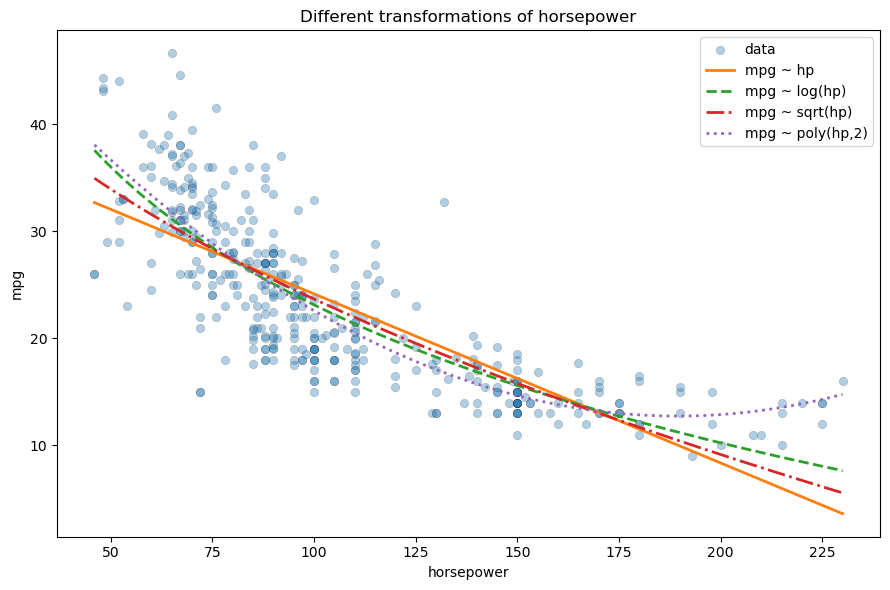

In [18]:
# plot all four fits on top of the data so the difference is visible
grid = pd.DataFrame({'horsepower': np.linspace(hp.min(), hp.max(), 200)})
grid['log_hp'] = np.log(grid['horsepower'])
grid['sqrt_hp'] = np.sqrt(grid['horsepower'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(hp, y, alpha=0.35, edgecolor='k', linewidth=0.3, label='data')

specs = {
    'mpg ~ hp':         (MS(['horsepower']),                 'C1', '-'),
    'mpg ~ log(hp)':    (MS(['log_hp']),                     'C2', '--'),
    'mpg ~ sqrt(hp)':   (MS(['sqrt_hp']),                    'C3', '-.'),
    'mpg ~ poly(hp,2)': (MS([poly('horsepower', degree=2)]), 'C4', ':'),
}
for name, (spec, color, ls) in specs.items():
    spec_f = spec.fit(Auto)
    yhat = models[name].predict(spec_f.transform(grid))
    ax.plot(grid['horsepower'], yhat, color=color, ls=ls, lw=2, label=name)

ax.set_xlabel('horsepower'); ax.set_ylabel('mpg')
ax.set_title('Different transformations of horsepower')
ax.legend()
plt.tight_layout()
plt.show()

**What I found.** The plain line is the weakest of the bunch (R-squared about 0.61), no surprise. Every transformation does better because they can all bend to follow the data:

- log(horsepower) was the winner here - highest R-squared (about 0.67) and lowest RSE.
- sqrt(horsepower) and the quadratic also clearly beat the straight line.

You can see it in the plot too: all three curves hug the data way better than the straight line, especially at the high-horsepower end where the line overshoots. So if I had to pick, I'd model mpg against log(horsepower) - it's simple and it fixes the curvature problem.

### 2. Classification

This question should be answered using the `Weekly` data set.

This dataset is weekly S&P 500 returns from 1990 to 2010. For each week we get five lagged returns (Lag1 through Lag5), the trading Volume, that week's return (Today), and whether the market went Up or Down (Direction) - that last one is what we're trying to predict.

In [19]:
Weekly = pd.read_csv('Weekly.csv')
print("Shape:", Weekly.shape)
print("Years covered:", Weekly['Year'].min(), "to", Weekly['Year'].max())
Weekly.head()

Shape: (1089, 9)
Years covered: 1990 to 2010


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


(a) [5 pts] Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [20]:
Weekly.describe().round(3)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000,1089.000
mean,2000.049,0.151,0.151,0.147,0.146,0.140,1.575,0.150
std,6.033,2.357,2.357,2.361,2.360,2.361,1.687,2.357
min,1990.000,-18.195,-18.195,-18.195,-18.195,-18.195,0.087,-18.195
25%,1995.000,-1.154,-1.154,-1.158,-1.158,-1.166,0.332,-1.154
50%,2000.000,0.241,0.241,0.241,0.238,0.234,1.003,0.241
75%,2005.000,1.405,1.409,1.409,1.409,1.405,2.054,1.405
max,2010.000,12.026,12.026,12.026,12.026,12.026,9.328,12.026


In [21]:
print("How often does the market go up vs down?")
print(Weekly['Direction'].value_counts())
print("\nFraction of Up weeks:", round((Weekly['Direction'] == 'Up').mean(), 4))

How often does the market go up vs down?
Direction
Up      605
Down    484
Name: count, dtype: int64

Fraction of Up weeks: 0.5556


In [22]:
# correlations - Direction gets dropped automatically since it's a label
Weekly_num = Weekly.drop(columns=['Direction'])
Weekly_num.corr().round(3)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000,-0.032,-0.033,-0.030,-0.031,-0.031,0.842,-0.032
Lag1,-0.032,1.000,-0.075,0.059,-0.071,-0.008,-0.065,-0.075
Lag2,-0.033,-0.075,1.000,-0.076,0.058,-0.072,-0.086,0.059
Lag3,-0.030,0.059,-0.076,1.000,-0.075,0.061,-0.069,-0.071
Lag4,-0.031,-0.071,0.058,-0.075,1.000,-0.076,-0.061,-0.008
Lag5,-0.031,-0.008,-0.072,0.061,-0.076,1.000,-0.059,0.011
Volume,0.842,-0.065,-0.086,-0.069,-0.061,-0.059,1.000,-0.033
Today,-0.032,-0.075,0.059,-0.071,-0.008,0.011,-0.033,1.000


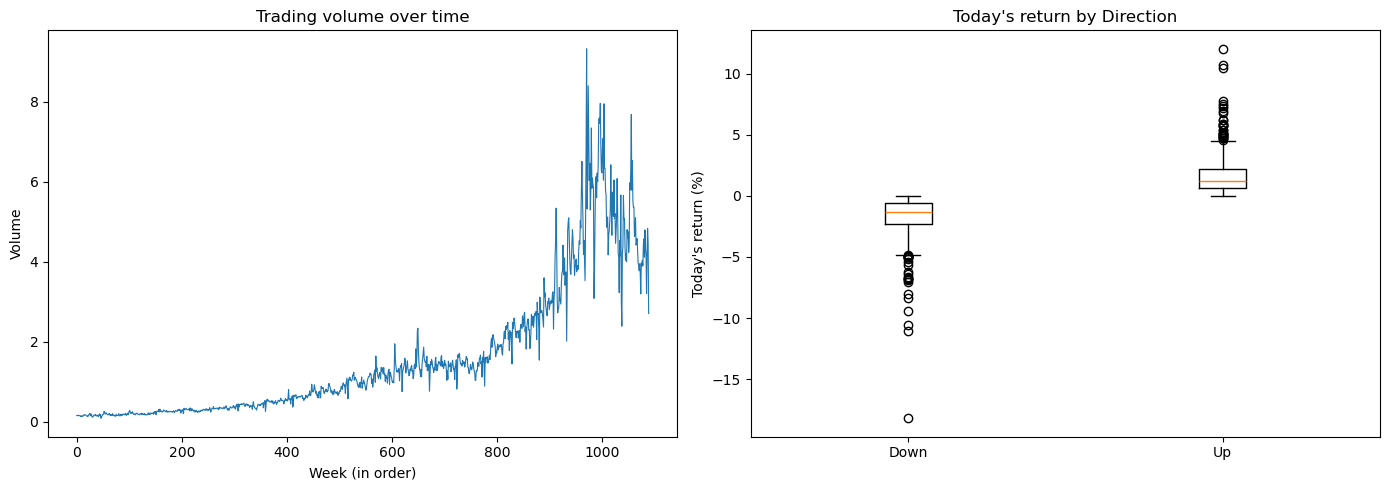

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# volume over time (row order = chronological)
axes[0].plot(Weekly.index, Weekly['Volume'], lw=0.8)
axes[0].set_xlabel('Week (in order)')
axes[0].set_ylabel('Volume')
axes[0].set_title('Trading volume over time')

# today's return split by direction
data_up = Weekly.loc[Weekly['Direction'] == 'Up', 'Today']
data_dn = Weekly.loc[Weekly['Direction'] == 'Down', 'Today']
axes[1].boxplot([data_dn, data_up], tick_labels=['Down', 'Up'])
axes[1].set_ylabel("Today's return (%)")
axes[1].set_title("Today's return by Direction")

plt.tight_layout()
plt.show()

**Are there patterns?** Honestly, not many - which is kind of the point with stock data. The one real relationship is between Year and Volume (correlation around 0.84), and you can see it in the left plot: trading volume just trends upward over the two decades. The lag variables, on the other hand, are basically uncorrelated with this week's return - all near zero. That's exactly what you'd expect if past returns don't really predict future ones. The classes lean slightly toward Up (about 56% vs 44%), worth keeping in mind later.

(b) [7 pts] Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [24]:
allvars = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
X_full = MS(allvars).fit_transform(Weekly)
y_full = (Weekly['Direction'] == 'Up')          # True means 'Up'

glm_full = sm.GLM(y_full, X_full, family=sm.families.Binomial()).fit()
summarize(glm_full)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


**Anything significant?** Just one thing: Lag2, with a p-value around 0.03 and a positive coefficient. Everything else - the other four lags and Volume - has a big p-value and doesn't look meaningful. So out of six predictors, only Lag2 seems to carry any real signal, and even that's not exactly overwhelming.

(c) [6 pts] Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [25]:
probs_full = glm_full.predict()
pred_full = np.where(probs_full > 0.5, 'Up', 'Down')

cm = confusion_table(pred_full, Weekly['Direction'])
print(cm)
print("\nOverall accuracy:", round(np.mean(pred_full == Weekly['Direction']), 4))

Truth      Down   Up
Predicted           
Down         54   48
Up          430  557

Overall accuracy: 0.5611


**What's the confusion matrix saying?** The overall accuracy is about 56%, which sounds okay until you realize you'd get the same 56% just by guessing "Up" every single time. And that's basically what the model *does* - look at the matrix: it predicts Up almost all the time. It nails most of the genuine Up weeks but also calls a huge number of Down weeks Up. So its main mistake is false positives - saying the market will rise when it actually falls. The accuracy is really just riding on the class imbalance, not on any real skill.

(d) [6 pts] Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [26]:
train = (Weekly['Year'] <= 2008)
test = ~train

X_lag2 = MS(['Lag2']).fit_transform(Weekly)
y_lag2 = (Weekly['Direction'] == 'Up')

Xtr, Xte = X_lag2[train], X_lag2[test]
ytr = y_lag2[train]
L_train = Weekly['Direction'][train]
L_test = Weekly['Direction'][test]

glm_d = sm.GLM(ytr, Xtr, family=sm.families.Binomial()).fit()
probs_d = glm_d.predict(Xte)
pred_d = np.where(probs_d > 0.5, 'Up', 'Down')

print(confusion_table(pred_d, L_test))
acc_logit = np.mean(pred_d == L_test)
print("\nLogistic regression test accuracy:", round(acc_logit, 4))

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56

Logistic regression test accuracy: 0.625


Now we're testing on data the model never saw (2009-2010). With only Lag2, logistic regression gets about 62.5% right. It still leans heavily toward predicting Up (catching 56 of 61 actual Up weeks) but the held-out accuracy is a real improvement over the full-sample mess in part (c).

For the sklearn classifiers below, I'll use the Lag2 column on its own - those estimators add their own intercept, so I drop the one ModelSpec made.

In [27]:
Xtr_sk = Xtr.drop(columns=['intercept'])
Xte_sk = Xte.drop(columns=['intercept'])

(e) [6 pts] Repeat (d) using LDA.

In [28]:
lda = LDA().fit(Xtr_sk, L_train)
pred_e = lda.predict(Xte_sk)

print(confusion_table(pred_e, L_test))
acc_lda = np.mean(pred_e == L_test)
print("\nLDA test accuracy:", round(acc_lda, 4))

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56

LDA test accuracy: 0.625


LDA gives the *exact same* confusion matrix and accuracy as logistic regression - 62.5%. Not a coincidence: with one predictor and roughly normal data, LDA and logistic regression draw almost the same decision boundary, so they end up agreeing.

(f) [6 pts] Repeat (d) using QDA.

In [29]:
qda = QDA().fit(Xtr_sk, L_train)
pred_f = qda.predict(Xte_sk)

print(confusion_table(pred_f, L_test))
acc_qda = np.mean(pred_f == L_test)
print("\nQDA test accuracy:", round(acc_qda, 4))

Truth      Down  Up
Predicted          
Down          0   0
Up           43  61

QDA test accuracy: 0.5865


QDA lands at about 58.7%. Interesting detail: it ends up predicting Up for *every* test week, so it's basically just matching the proportion of Up weeks in 2009-2010 and not really distinguishing anything.

(g) [6 pts] Repeat (d) using KNN with $K=1$.

In [30]:
knn1 = KNeighborsClassifier(n_neighbors=1).fit(Xtr_sk, L_train)
pred_g = knn1.predict(Xte_sk)

print(confusion_table(pred_g, L_test))
acc_knn1 = np.mean(pred_g == L_test)
print("\nKNN (K=1) test accuracy:", round(acc_knn1, 4))

Truth      Down  Up
Predicted          
Down         21  30
Up           22  31

KNN (K=1) test accuracy: 0.5


KNN with K=1 is the worst of the lot - about 49%, which is basically a coin flip. With a single neighbor the model is way too flexible; it just memorizes the training noise and falls apart on new data.

(h) [6 pts] Repeat (d) using naive Bayes.

In [31]:
nb = GaussianNB().fit(Xtr_sk, L_train)
pred_h = nb.predict(Xte_sk)

print(confusion_table(pred_h, L_test))
acc_nb = np.mean(pred_h == L_test)
print("\nNaive Bayes test accuracy:", round(acc_nb, 4))

Truth      Down  Up
Predicted          
Down          0   0
Up           43  61

Naive Bayes test accuracy: 0.5865


Naive Bayes ends up doing the same thing QDA did - predicting Up every week and landing at 58.7%.

(i) [6 pts] Which of these methods appears to provide the best results on this data?

In [32]:
summary = pd.DataFrame({
    'Method': ['Logistic regression', 'LDA', 'QDA', 'Naive Bayes', 'KNN (K=1)'],
    'Test accuracy': [acc_logit, acc_lda, acc_qda, acc_nb, acc_knn1]
}).sort_values('Test accuracy', ascending=False).reset_index(drop=True)
summary['Test accuracy'] = summary['Test accuracy'].round(4)
summary

,Method,Test accuracy
0,Logistic regression,0.6250
1,LDA,0.6250
2,QDA,0.5865
3,Naive Bayes,0.5865
4,KNN (K=1),0.5000


So lining them all up: logistic regression and LDA tie for first at 62.5%. QDA and Naive Bayes are next at 58.7%, and KNN with K=1 brings up the rear at 49%. For this dataset and this particular train/test split, the two linear methods using Lag2 come out on top.

(j) [6 pts] Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for $K$ in the KNN classifier.

### (j) Messing around with predictors, transformations, interactions, and K [6 pts]

This is the open-ended part, so I tried a bunch of combinations to see if I could beat that 62.5%. I'll dump them all in a table and then show the confusion matrix for whatever wins.

In [33]:
results_j = []

def eval_logit(formula_terms, label):
    Xj = MS(formula_terms).fit_transform(Weekly)
    g = sm.GLM(y_lag2[train], Xj[train], family=sm.families.Binomial()).fit()
    p = g.predict(Xj[test])
    pred = np.where(p > 0.5, 'Up', 'Down')
    results_j.append((label, np.mean(pred == L_test)))

# logistic variants
eval_logit(['Lag2'], 'Logit: Lag2')
eval_logit(['Lag1', 'Lag2'], 'Logit: Lag1+Lag2')
eval_logit(['Lag2', ('Lag1', 'Lag2')], 'Logit: Lag2 + Lag1:Lag2')
eval_logit(['Lag1', 'Lag2', 'Lag3'], 'Logit: Lag1+Lag2+Lag3')

# the other classifiers on Lag1+Lag2
def eval_sklearn(clf, cols, label):
    Xc = MS(cols).fit_transform(Weekly).drop(columns=['intercept'])
    clf.fit(Xc[train], L_train)
    pred = clf.predict(Xc[test])
    results_j.append((label, np.mean(pred == L_test)))

eval_sklearn(LDA(), ['Lag1', 'Lag2'], 'LDA: Lag1+Lag2')
eval_sklearn(QDA(), ['Lag1', 'Lag2'], 'QDA: Lag1+Lag2')
eval_sklearn(GaussianNB(), ['Lag1', 'Lag2'], 'NB: Lag1+Lag2')

# KNN across a range of K (this is the tuning the question asks for)
for K in [1, 3, 5, 10, 20, 50, 100]:
    eval_sklearn(KNeighborsClassifier(n_neighbors=K), ['Lag2'], f'KNN(K={K}): Lag2')

tbl = pd.DataFrame(results_j, columns=['Method', 'Test accuracy'])
tbl['Test accuracy'] = tbl['Test accuracy'].round(4)
tbl.sort_values('Test accuracy', ascending=False).reset_index(drop=True)

,Method,Test accuracy
0,Logit: Lag2,0.6250
1,KNN(K=20): Lag2,0.5962
2,Logit: Lag2 + Lag1:Lag2,0.5865
3,Logit: Lag1+Lag2,0.5769
4,Logit: Lag1+Lag2+Lag3,0.5769
5,LDA: Lag1+Lag2,0.5769
6,KNN(K=10): Lag2,0.5673
7,KNN(K=50): Lag2,0.5673
8,KNN(K=100): Lag2,0.5673
9,QDA: Lag1+Lag2,0.5577


In [34]:
# the winner ended up being the plain Lag2 logistic model again
print("Best model: logistic regression with Lag2 only (62.5%)\n")
print(confusion_table(pred_d, L_test))

Best model: logistic regression with Lag2 only (62.5%)

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56


**The verdict.** After all that experimenting - extra lags, a Lag1:Lag2 interaction, running LDA/QDA/Naive Bayes on Lag1+Lag2, and sweeping KNN across K from 1 to 100 - nothing actually beat the dead-simple logistic regression (or LDA) on Lag2 alone at 62.5%. A couple of takeaways:

- Adding more lags or the interaction term didn't help and usually made things slightly worse. The extra predictors are mostly noise, and noise just adds variance without buying you any real signal.
- For KNN, the sweet spot was around K = 20 (about 59-60%), still short of the linear models. Tiny K (especially 1) overfits hard, as we already saw.

So the best model is logistic regression / LDA with Lag2, whose confusion matrix is right above - it predicts Up most weeks and correctly catches 56 of the 61 real Up weeks. Which, stepping back, fits the bigger picture: weekly market returns are genuinely hard to predict, and whatever tiny edge exists gets picked up just fine by a simple linear model on Lag2. No need to overcomplicate it.